# Analyze and plot the results of linear treadmill with reward simulation

### Import

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
scenario = "linear_reward"
trial_number = 10
use_example = True
save_plot = False

In [ ]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "trial"
data_path = os.path.join(base_path,"data",scenario) if use_example else os.path.join(base_path,"results",scenario)

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

# Add the directory to sys.path
ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

from global_variables import *
from linear_reward_variables import *
from linear_reward_functions import *
from plots import *

# Fig. 2, Familiarization

### Fig 2c, Plot averaged weights

In [10]:
load_lap = 5

CA3_weights = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))
CA1_weights = np.zeros((num_CA1_neurons,num_CA3_neurons,len(target_seed)))

for ii,seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))
    CA3_weights[:,:,ii] = ff["w_CA3_CA3"]; CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%(load_lap)))
    place_field_sorted_idx = np.array(list(CA1_place_fields.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights[:,:,ii] = CA1_temp[:,place_cue_mix_idx]


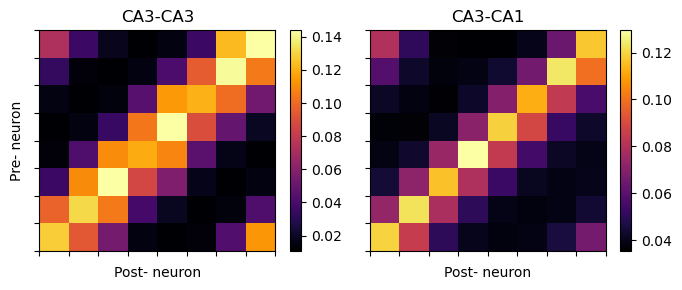

In [263]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
CA1_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_wmx_arr[:,:,seed] = average_weight(CA3_weights[:,:,seed], n_pops, n_pops)
    CA1_mean_wmx_arr[:,:,seed] = average_weight(CA1_weights[:,:,seed], n_pops, n_pops)

CA3_mean_wmx = CA3_mean_wmx_arr.mean(-1)
CA1_mean_wmx = CA1_mean_wmx_arr.mean(-1)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA3_mean_wmx, fig=fig, ax=axs[0], title="CA3-CA3")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA1_mean_wmx, fig=fig, ax=axs[1], title="CA3-CA1")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"avg_hippocampal_weights_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig 2d, Plot center-aligned weights

In [20]:
unit_gran = 4; state_window = 4

target_state = np.arange(num_state_total)

CA3_aligned = np.zeros((unit_gran*len(target_state)*len(target_seed),2*unit_gran*state_window+1))
CA1_aligned = np.zeros((unit_gran*len(target_state)*len(target_seed),2*unit_gran*state_window+1))

for ii, seed in enumerate(target_seed):

    CA3_mean_wmx = average_weight(CA3_weights[:,:,ii], unit_gran*len(target_state), unit_gran*len(target_state))
    CA3_aligned[ii*unit_gran*len(target_state):(ii+1)*unit_gran*len(target_state),:] = extract_aligned_activity(CA3_mean_wmx, np.argmax(CA3_mean_wmx,axis=1), unit_gran*state_window)

    CA1_mean_wmx = average_weight(CA1_weights[:,:,ii], unit_gran*len(target_state), unit_gran*len(target_state))
    CA1_aligned[ii*unit_gran*len(target_state):(ii+1)*unit_gran*len(target_state),:] = extract_aligned_activity(CA1_mean_wmx, np.argmax(CA1_mean_wmx,axis=1), unit_gran*state_window)

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3214260/2055916614.py:11: SyntaxWarning: invalid escape sequence '\D'
  axs[0].set_xticklabels(["-4","-2","0","2","4"]); axs[0].set_xlabel("$\Delta t_{post-pre}$(s)")
/tmp/ipykernel_3214260/2055916614.py:16: SyntaxWarning: invalid escape sequence '\D'
  axs[1].set_xticklabels(["-4","-2","0","2","4"]); axs[1].set_xlabel("$\Delta t_{post-pre}$(s)")


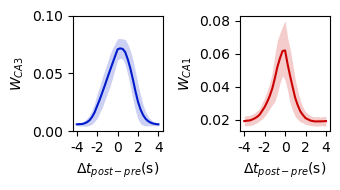

In [32]:
CA3_area = np.sum(CA3_aligned,axis=1)
CA3_norm = CA3_aligned/np.tile(CA3_area,(CA3_aligned.shape[1],1)).T
CA1_area = np.sum(CA1_aligned,axis=1)
CA1_norm = CA1_aligned/np.tile(CA1_area,(CA1_aligned.shape[1],1)).T

fig, axs = plt.subplots(1,2,figsize=(3.5, 2))
xx = np.arange(2*state_window*unit_gran+1)

axs[0] = plot_shaded(xx,CA3_norm.mean(0),CA3_norm.std(0),axs[0],color=[0,.1,.8])
axs[0].set_xticks(np.linspace(0,len(CA1_norm.mean(0))-1,5),[])
axs[0].set_xticklabels(["-4","-2","0","2","4"]); axs[0].set_xlabel("$\Delta t_{post-pre}$(s)")
axs[0].set_yticks(np.linspace(0.0,0.1,3)); axs[0].set_ylabel("$W_{CA3}$")

axs[1] = plot_shaded(xx,CA1_norm.mean(0),CA1_norm.std(0),axs[1],color=[0.8,0,0])
axs[1].set_xticks(np.linspace(0,len(CA1_norm.mean(0))-1,5))
axs[1].set_xticklabels(["-4","-2","0","2","4"]); axs[1].set_xlabel("$\Delta t_{post-pre}$(s)")
axs[1].set_yticks(np.linspace(0.02,0.08,4)); axs[1].set_ylabel("$W_{CA1}$")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"weight_symmetry_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

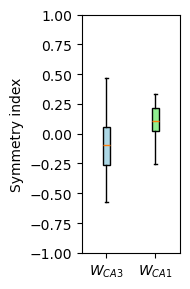

CA3 vs CA1 symmetry p val: 3.3492852760417365e-33


In [39]:
CA3_b = np.sum(CA3_aligned[:,:state_window*unit_gran+1],axis=1)
CA1_b = np.sum(CA1_aligned[:,:state_window*unit_gran+1],axis=1)
CA3_a = np.sum(CA3_aligned[:,state_window*unit_gran:],axis=1)
CA1_a = np.sum(CA1_aligned[:,state_window*unit_gran:],axis=1)

fig, ax = plt.subplots(1,1,figsize=(2, 3))
plot_box((CA3_b-CA3_a)/CA3_area, (CA1_b-CA1_a)/CA1_area, ax)

ax.set_xticklabels(['$W_{CA3}$', '$W_{CA1}$'])
ax.set_ylim([-1,1]); ax.set_ylabel("Symmetry index")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"Weight_symmetry_box_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

_, p_value = stats.ttest_rel((CA3_b-CA3_a)/CA3_area, (CA1_b-CA1_a)/CA1_area)
print("CA3 vs CA1 symmetry p val:",p_value)

### Fig 2j, Spontaneous offline activity

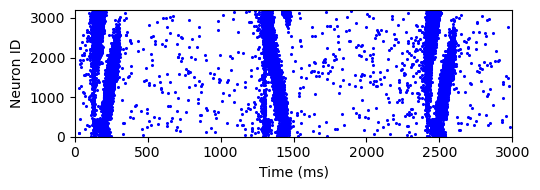

In [249]:
example_seed = target_seed[0]; load_lap = 5

CA3_place_fields = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_place_fields.keys()),dtype=int), np.array(list(CA3_place_fields.values())))
target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_place_fields,np.arange(num_state_col))

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA3_replay_lap_%d.npz"%(load_lap)))
spike_times_CA3_PC = ff['spike_times_CA3_PC']; spiking_neurons_CA3_PC = ff['spiking_neurons_CA3_PC']; rate_CA3_PC = ff['rate_CA3_PC']
del ff

fig, ax = plt.subplots(1,1,figsize=(5.5,2))
plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx, zoom_to=rest_time, ax=ax)
ax.set_ylim([0, num_CA3_neurons])

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Spontaneous_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

In [ ]:
replay, replay_results = analyse_replay(spike_times_CA3_PC, spiking_neurons_CA3_PC, rate_CA3_PC, verbose=True)
replay_time = list(replay_results.keys())[0]

Detecting replay:   0%|          | 0/3 [00:00<?, ?it/s]

Detecting replay: 100%|██████████| 3/3 [00:20<00:00,  6.79s/it]

Replay detected!


(array([97, 98, 99]),)


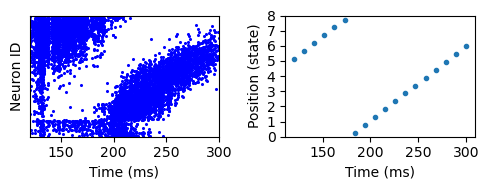

In [251]:
fig,axs = plt.subplots(1,2,figsize=(5,2))

plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx,
               zoom_from=replay_time[0], zoom_to=replay_time[1], ax=axs[0])
axs[0].set_ylim([0, num_CA3_neurons]); axs[0].set_yticks([]); axs[0].set_ylabel("Neuron ID")

path = replay_results[(replay_time[0], replay_time[1])]['fitted_path']
path[path<0] = unit_gran*num_state_total+path[path<0]
path[path>unit_gran*num_state_total] = path[path>unit_gran*num_state_total]-unit_gran*num_state_total
axs[1].plot(np.linspace(replay_time[0], replay_time[1], path.size), num_state_total*path/(4*num_state_total),'.')
axs[1].set_yticks(np.linspace(0,num_state_total,num_state_total+1))
axs[1].set_xlabel("Time (ms)")
print(np.where(replay_results[(replay_time[0], replay_time[1])]['shuffled_Rs']>replay_results[(replay_time[0], replay_time[1])]['R']))
axs[1].set_ylim([0, num_state_total]); axs[1].set_ylabel("Position (state)")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Zoomed_in_replay_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig 2i, Emergence of place cells

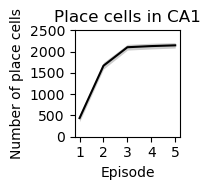

In [62]:
target_lap= np.arange(5)+1
PC_count = np.zeros((len(target_seed),len(target_lap)),dtype=int)
for ii,mm in enumerate(target_seed):
    foldername = folder_root+str(mm)
    for ee in range(len(target_lap)):
        CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(target_lap[ee])+".pkl"))
        PC_count[ii,ee] = len(CA1_place_fields)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax = plot_shaded(target_lap,PC_count.mean(0),PC_count.std(0),ax,color='black')
ax.set_xlabel("Episode"); ax.set_xticks(target_lap)
ax.set_yticks(np.linspace(0,2500,6))
ax.set_ylabel("Number of place cells")
ax.set_title("Place cells in CA1")
plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"total_CA1_PC_count.png"), dpi=300)
plt.show()

### Fig 2j, Simulated place cell activity

In [64]:
load_lap = 5
seed = target_seed[0]
foldername = folder_root + str(seed)

CA1_activity = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["CA1_activity"]
place_thr_FR = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["place_thr_FR"]
w_CA3_CA1 = CA1_mean_wmx_arr[:,:,load_lap-1]
CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))

place_field_sorted_idx = np.array(list(CA1_PF.keys()))
place_div_idx = np.hstack((place_field_sorted_idx,np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)))

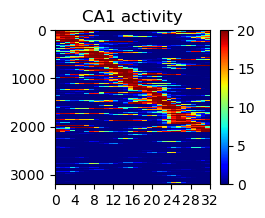

In [67]:
xlab = []

for ii in range(num_state_total):
    xlab.append("%d"%(ii))

data = CA1_activity[:, place_div_idx].T
x = np.arange(data.shape[1] + 1)
y = np.arange(data.shape[0] + 1)

#place_field_sorted_idx
fig, ax = plt.subplots(1, 1,figsize=(2.5, 2))
fig, ax = plot_heatmap(data, fig, ax, title="CA1 activity", cmap="jet", vmin=0, vmax=max_input_FR)
plt.gca().yaxis.set_inverted(True)
ax.set_xticks(np.linspace(0,int(data.shape[1]/num_state_total)*num_state_total,num_state_total+1))

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig 2k, Averaged place field

<>:52: SyntaxWarning: invalid escape sequence '\g'
<>:52: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3214260/1711847441.py:52: SyntaxWarning: invalid escape sequence '\g'
  axs[1].set_ylabel("Discount factor ($\gamma$)")
/tmp/ipykernel_3214260/1711847441.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xlabel('Time (s)'); axs[0].set_xticklabels(["-3","-2","-1","0","1","2","3"])


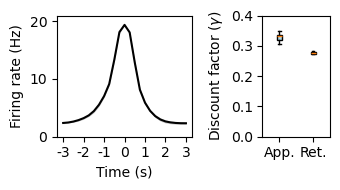

Approach vs. retreat p:  4.094090077141758e-06


In [130]:
peak_idx = find_PF_peak(CA1_activity)
act_window = int(3*unit_gran)
mid = act_window

x_approach = np.arange(mid+1)/unit_gran       # moving into the field
x_retreat = x_approach   # moving away from the field

mult_app, gamma_app, baseline_app = list(), list(), list()
mult_ret, gamma_ret, baseline_ret = list(), list(), list()

all_act = extract_aligned_activity(CA1_activity,peak_idx,act_window)
avg_PF = np.mean(all_act,axis=0)

app_mean = all_act[:, :mid+1].mean(0); ret_mean = all_act[:, mid:].mean(0)

popt_app, fit_app, stats_app = curve_fit_calc(x_approach, app_mean[::-1], exponential_func)
popt_ret, fit_ret, stats_ret = curve_fit_calc(x_retreat, ret_mean, exponential_func)

mult_app.append(popt_app[0]); gamma_app.append(popt_app[1]); baseline_app.append(popt_app[2])#gamma_app[cellID], baseline_app[cellID] = popt_app
mult_ret.append(popt_ret[0]); gamma_ret.append(popt_ret[1]); baseline_ret.append(popt_ret[2])

for seed in target_seed[1:]:
    foldername = folder_root + str(seed)
    
    temp_array = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["CA1_activity"]
    temp_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))
    all_idx = list(temp_PF.keys())
    
    peak_idx = find_PF_peak(temp_array)
    all_act = extract_aligned_activity(temp_array[:,all_idx],peak_idx[all_idx],act_window)
    avg_PF = np.vstack((avg_PF,np.mean(all_act,axis=0)))

    app_mean = all_act[:, :mid+1].mean(0)
    ret_mean = all_act[:, mid:].mean(0)
                            
    popt_app, fit_app, stats_app = curve_fit_calc(x_approach, app_mean[::-1], exponential_func)
    popt_ret, fit_ret, stats_ret = curve_fit_calc(x_retreat, ret_mean, exponential_func)

    mult_app.append(popt_app[0]); gamma_app.append(popt_app[1]); baseline_app.append(popt_app[2])#gamma_app[cellID], baseline_app[cellID] = popt_app
    mult_ret.append(popt_ret[0]); gamma_ret.append(popt_ret[1]); baseline_ret.append(popt_ret[2])

xx = np.arange(-act_window, act_window + 1)
fig, axs = plt.subplots(1, 2, width_ratios=(2,1), figsize=(3.5, 2))
plot_shaded(xx,avg_PF.mean(0),avg_PF.std(0),axs[0])
axs[0].set_xlabel('Time (s)'); axs[0].set_xticklabels(["-3","-2","-1","0","1","2","3"])
axs[0].set_ylabel('Firing rate (Hz)'); axs[0].set_ylim([0,max_input_FR+1])
axs[0].set_xticks(np.linspace(-act_window,act_window,2*act_window//unit_gran+1))

plot_box(gamma_app, gamma_ret, axs[1])
axs[1].set_xticklabels(["App.","Ret."])
axs[1].set_ylim([0.0,0.4]); axs[1].set_yticks(np.linspace(0,0.4,5))
axs[1].set_ylabel("Discount factor ($\gamma$)")

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Assymetric_place_field.png"), dpi=300)
plt.show()

_, p_value = stats.ttest_rel(gamma_app, gamma_ret)
print("Approach vs. retreat p: ",p_value)


### Fig. 2m, Trained feature prediction layer weight

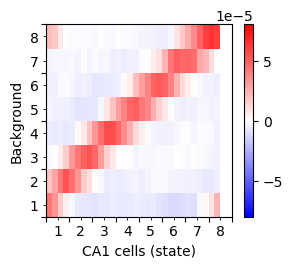

In [194]:
w_CA1_feat = np.zeros((num_CA1_neurons,num_features,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    w = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))["w_CA1_feat"]
    CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))
    CA1_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA1_PF.keys()),dtype=int), np.array(list(CA1_PF.values())))
    CA1_target_idx = reorder_neuron_idx(CA1_place_cell_ID_list,CA1_PF,np.arange(num_state_total),include_cue=True)
    w_CA1_feat[:,:,ii] = w[CA1_target_idx,:]
    del CA1_PF, CA1_place_cell_ID_list

n_pops = num_state_total*unit_gran
mean_wmxs = np.zeros((n_pops, num_features, len(target_seed)))
for seed in target_seed:
    weightmx = w_CA1_feat[:,:,seed]
    mean_wmxs[:,:,seed] = average_weight(weightmx, num_features, n_pops)

mean_wmxs = mean_wmxs[2:] # exclude the first two features (reward and reward prediction error) to focus on the state representation
mmax = 8e-5

fig, ax = plt.subplots(1,1, figsize=(3, 2.5))
plot_heatmap(mean_wmxs.mean(-1).T, fig, ax, title="", vmin=-mmax, vmax=mmax, cmap="bwr")
ax.set_ylim([2,num_features]); ax.set_yticklabels([])
ax.set_yticks(np.arange(2,num_features)+0.5, minor=True)
ax.set_yticklabels(np.array(np.arange(num_features-2)+1,dtype=str), minor=True)

ax.set_xticks(np.arange(0,n_pops+1,unit_gran)); ax.set_xticklabels([])
ax.set_xticks(np.arange(unit_gran//2,n_pops-1,unit_gran), minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("Background"); ax.set_xlabel("CA1 cells (state)")

if save_plot: plt.savefig(os.path.join(plot_path,"feature_prediction_weight_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 2n, Simulated background feature unit activity

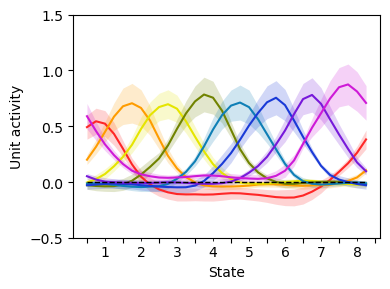

In [ ]:
target_lap = np.arange(15)+1
feat_pred = np.zeros((num_features,unit_gran*num_state_total,len(target_lap),len(target_seed)))

for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    for ee, lap in enumerate(target_lap):
        w = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%lap))["w_CA1_feat"]
        act = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_%d.npz"%lap))["CA1_activity"]
        prediction = (act@w).T
        feat_pred[:,:,ee,mm] = prediction

bg_linecolor = np.array([[255,39,39],[255,157,0],[230,230,0],[113,132,0],[15,127,183],[26,58,216],[119,25,219],[207,26,216]])/256
plot_episode = 5

fig, ax = plt.subplots(1,1,figsize=(4,3))
xx = np.arange(feat_pred.shape[1])
episode_pred = feat_pred[:,:,plot_episode-1,:]

for bg in range(num_state_total):
    ax = plot_shaded(xx,episode_pred[bg+2].mean(-1),episode_pred[bg+2].std(-1),ax,list(bg_linecolor[bg]))
plt.hlines(0, color='k', linestyle='--', linewidth=1, xmin=0, xmax=episode_pred.shape[1]-1)

ax.set_ylim([-.5,1.5]); ax.set_yticks(np.arange(-0.5,1.6,0.5))
ax.set_xticks(np.linspace(0,feat_pred.shape[1],num_state_total+1))
ax.set_xticks(np.arange(0,n_pops+1,unit_gran)); ax.set_xticklabels([])
ax.set_xticks(np.arange(unit_gran//2,n_pops-1,unit_gran), minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("Unit activity"); ax.set_xlabel("State")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"background_unit_activity_lap_%d.png"%plot_episode), dpi=300)
plt.show()

### Fig. 2o, Averaged feature field

<>:37: SyntaxWarning: invalid escape sequence '\g'
<>:37: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3214260/2142459311.py:37: SyntaxWarning: invalid escape sequence '\g'
  axs[1].set_ylabel("Discount factor ($\gamma$)")


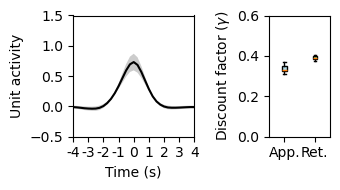

Approach vs. retreat p:  1.1614385422183256e-05


In [237]:
act_window = int(4 * unit_gran)

mid = 3*unit_gran*num_state_total//2
x_approach = np.arange(act_window)/unit_gran       # moving into the field
x_retreat = np.arange(act_window)/unit_gran   # moving away from the field

mult_app, gamma_app, baseline_app = list(), list(), list()
mult_ret, gamma_ret, baseline_ret = list(), list(), list()
p0=[0.5, 0.1, 0]
bounds=([0.1, 1e-6, -0.2], [20, 1-1e-9, 0.5])

aligned_pred = np.zeros((mid*2,len(target_seed)))
for mm in target_seed:
    temp_prediction = np.zeros((unit_gran*num_state_total,num_features-2))
    for ss in range(num_state_total):
        temp_prediction[:,ss] = np.roll(episode_pred[ss+2,:,mm],int((-ss+4)*unit_gran-1))
    aligned_pred[:,mm] = np.tile(temp_prediction,(3,1)).mean(-1)

    popt_app, fit_app, stats_app = curve_fit_calc(x_approach, aligned_pred[mid-act_window:mid,mm][::-1], exponential_func, p0=p0,bounds=bounds)
    popt_ret, fit_ret, stats_ret = curve_fit_calc(x_retreat, aligned_pred[mid:mid+act_window,mm], exponential_func, p0=p0,bounds=bounds)

    mult_app.append(popt_app[0]); gamma_app.append(popt_app[1]); baseline_app.append(popt_app[2])#gamma_app[cellID], baseline_app[cellID] = popt_app
    mult_ret.append(popt_ret[0]); gamma_ret.append(popt_ret[1]); baseline_ret.append(popt_ret[2])

mean_pred = np.mean(aligned_pred[:,2:],axis=1); std_pred = np.std(aligned_pred[:,2:],axis=1)

fig, axs = plt.subplots(1, 2, width_ratios=(2,1), figsize=(3.5, 2))
axs[0] = plot_shaded(np.arange(mid*2), aligned_pred.mean(1), aligned_pred.std(1), axs[0])
axs[0].set_xlim([16-act_window,16+act_window]); axs[0].set_xticks(np.linspace(0,episode_pred[0,:,:].shape[0],num_state_total+1))
axs[0].set_xticklabels(np.array(np.arange(9)-4,dtype=str)); axs[0].set_xlabel("Time (s)")
axs[0].set_ylim([-.5,1.5]); axs[0].set_yticks(np.arange(-0.5,1.6,0.5))
axs[0].set_ylabel("Unit activity")

plot_box(gamma_app, gamma_ret, axs[1])
axs[1].set_xticklabels(["App.","Ret."])
axs[1].set_ylim([0.0,0.6]); axs[1].set_yticks(np.linspace(0,0.6,4))
axs[1].set_ylabel("Discount factor ($\gamma$)")

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Assymetric_feature_field.png"), dpi=300)
plt.show()

_, p_value = stats.ttest_rel(gamma_app, gamma_ret)
print("Approach vs. retreat p: ",p_value)


# Figure 3. Reward introduction

### Load

In [239]:
trajectory = np.arange(num_state_total)
feat_episode = [np.arange(6,11),np.arange(11,16)]
feat_state = np.array([3,num_state_total-1])
feat_ID = 0
feat_speed = feature_speed[feat_ID]

from plots import create_gradient
grad1 = create_gradient([.8,.5,.5], [.9,0,0], 6)
grad2 = create_gradient([68/256,136/256,246/256], [0,0,.8], 5)
colors = np.tile([0,0,0],(5,1)) 
colors = np.vstack((colors,grad1[:-1]))
colors = np.vstack((colors,grad2))

target_episode = np.arange(1,16)

windows_per_state = steps_per_unit*np.ones((len(target_episode),len(trajectory)),dtype=int)

for case in range(len(feat_state)):
    feat_episode_case = feat_episode[case]
    feat_state_case = feat_state[case]
    windows_per_state[np.intersect1d(target_episode,feat_episode_case)-1,trajectory==feat_state_case] = int(steps_per_unit/feat_speed)

windows_per_state = np.cumsum(windows_per_state,axis=1)
windows_per_state = np.hstack((np.zeros((len(target_episode),1),dtype=int),windows_per_state))

### Fig. 3c, Perceived salience

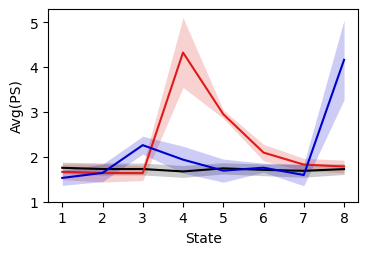

In [ ]:
mean_PS = np.zeros((len(target_seed),len(target_episode),num_state_total))
max_PS = np.zeros((len(target_seed),len(target_episode),num_state_total))

for mm, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, load_ep in enumerate(target_episode):
        PS_episode = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_ep)))["PS_list"]
        for ss in range(num_state_total):
            for idx in np.where(trajectory==ss)[0]:
                timeframe = np.arange(windows_per_state[ee,idx],windows_per_state[ee,idx+1])
                mean_PS[mm,ee,ss] = PS_episode[timeframe].mean()
                max_PS[mm,ee,ss] = np.max(PS_episode[timeframe])

fig, axs = plt.subplots(1, 2, figsize=(7,2.5))

xx = np.arange(num_state_total)+1

data_noRW = mean_PS[:,4,:].reshape(-1,num_state_total)
data_RW = mean_PS[:,5,:].reshape(-1,num_state_total)
data_rmv = mean_PS[:,10,:].reshape(-1,num_state_total)

ax = plot_shaded(xx,data_noRW.mean(0),data_noRW.std(0),ax,colors[4])
ax = plot_shaded(xx,data_RW.mean(0),data_RW.std(0),ax,colors[9])
ax = plot_shaded(xx,data_rmv.mean(0),data_rmv.std(0),ax,colors[14])
plt.yticks(np.arange(1,6)); plt.xticks(xx)
ax.set_ylabel("Avg(PS)"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"Perceived_salience.png"), dpi=300)
plt.show()

Before RW, state 4 vs. others, p val 0.2684999997800136
Before RW, state 8 vs. others, p val 0.9840995582417837
After RW, state 4 vs. others, p val 2.9044939947273083e-19
After RW, state 8 vs. others, p val 0.25273168575044974
After removal, state 4 vs. others, p val 0.08028544410110475
After removal, state 8 vs. others, p val 2.4090186778793936e-24


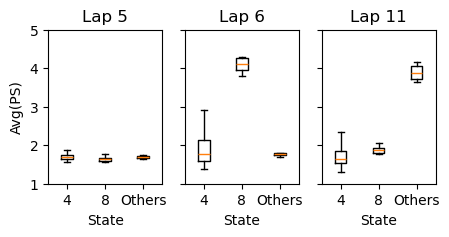

In [273]:
fig, axs = plt.subplots(1,3,figsize=(5,2))

axs[0].boxplot([data_noRW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_noRW[:,feat_state[0]].flatten(),data_noRW[:,feat_state[1]].flatten()], showfliers=False)
axs[0].set_ylim([1,5]); axs[0].set_xticklabels(["4","8","Others"]); axs[0].set_xlabel("State")
axs[0].set_title("Lap 5"); axs[0].set_ylabel("Avg(PS)")
_,p_val = stats.ttest_ind(data_noRW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_noRW[:,feat_state[0]].flatten())
print("Before RW, state %d vs. others, p val"%(feat_state[0]+1),p_val)
_,p_val = stats.ttest_ind(data_noRW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_noRW[:,feat_state[1]].flatten())
print("Before RW, state %d vs. others, p val"%(feat_state[1]+1),p_val)

axs[1].boxplot([data_RW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_RW[:,feat_state[0]].flatten(),data_RW[:,feat_state[1]].flatten()], showfliers=False)
axs[1].set_ylim([1,5]); axs[1].set_yticklabels(""); axs[1].set_xticklabels(["4","8","Others"]); axs[1].set_xlabel("State")
axs[1].set_title("Lap 6")
_,p_val = stats.ttest_ind(data_RW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_RW[:,feat_state[0]].flatten())
print("After RW, state %d vs. others, p val"%(feat_state[0]+1),p_val)
_,p_val = stats.ttest_ind(data_RW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_RW[:,feat_state[1]].flatten())
print("After RW, state %d vs. others, p val"%(feat_state[1]+1),p_val)

axs[2].boxplot([data_rmv[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_rmv[:,feat_state[0]].flatten(),data_rmv[:,feat_state[1]].flatten()], showfliers=False)
axs[2].set_ylim([1,5]); axs[2].set_yticklabels(""); axs[2].set_xticklabels(["4","8","Others"]); axs[2].set_xlabel("State")
axs[2].set_title("Lap 11")
_,p_val = stats.ttest_ind(data_rmv[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_rmv[:,feat_state[0]].flatten())
print("After removal, state %d vs. others, p val"%(feat_state[0]+1),p_val)
_,p_val = stats.ttest_ind(data_rmv[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_rmv[:,feat_state[1]].flatten())
print("After removal, state %d vs. others, p val"%(feat_state[1]+1),p_val)

### Fig. 3d, CA3 network evolvement

In [246]:
before_lap = 10; after_lap = 15

CA3_weights_before = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))
CA3_weights_after = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(before_lap)))
    CA3_weights_before[:,:,ii] = ff["w_CA3_CA3"]
    del ff
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(after_lap)))
    CA3_weights_after[:,:,ii] = ff["w_CA3_CA3"]
    del ff

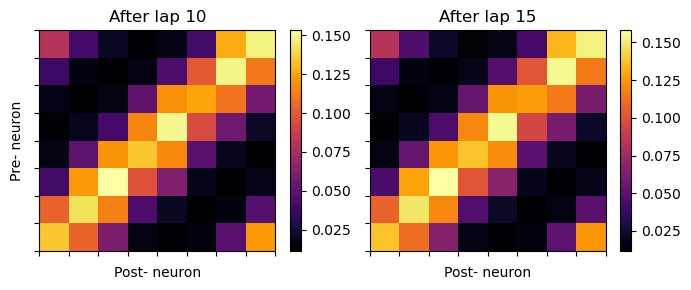

In [258]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_before = np.zeros((n_pops,n_pops,len(target_seed)))
CA3_mean_after = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_before[:,:,seed] = average_weight(CA3_weights_before[:,:,seed], n_pops, n_pops)
    CA3_mean_after[:,:,seed] = average_weight(CA3_weights_after[:,:,seed], n_pops, n_pops)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA3_mean_before.mean(-1), fig=fig, ax=axs[0], title="After lap 10")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA3_mean_after.mean(-1), fig=fig, ax=axs[1], title="After lap 15")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"CA3_weights_reward_relocation.png"), dpi=300)
plt.show()

### Fig. 3e, CA1 network evolvement

In [279]:
before_lap = 10; after_lap = 15

CA1_weights_before = np.zeros((num_CA1_neurons,num_CA1_neurons,len(target_seed)))
CA1_weights_after = np.zeros((num_CA1_neurons,num_CA1_neurons,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(before_lap)))
    CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_PF_before = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(before_lap)+".pkl"))
    place_field_sorted_idx = np.array(list(CA1_PF_before.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights_before[:,:,ii] = CA1_temp[:,place_cue_mix_idx]
    del CA1_temp, CA1_PF_before
        
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(after_lap)))
    CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_PF_after = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(after_lap)+".pkl"))
    place_field_sorted_idx = np.array(list(CA1_PF_after.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights_after[:,:,ii] = CA1_temp[:,place_cue_mix_idx]
    del CA1_temp, CA1_PF_after


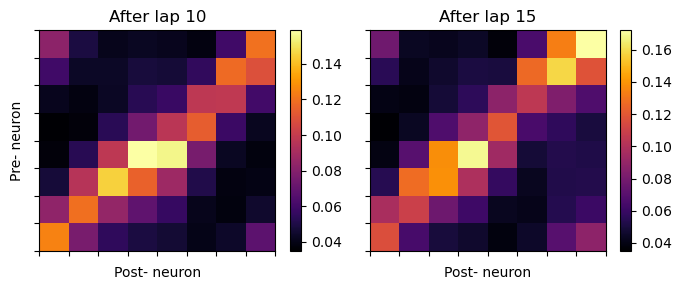

In [280]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA1_mean_before = np.zeros((n_pops,n_pops,len(target_seed)))
CA1_mean_after = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA1_mean_before[:,:,seed] = average_weight(CA1_weights_before[:,:,seed], n_pops, n_pops)
    CA1_mean_after[:,:,seed] = average_weight(CA1_weights_after[:,:,seed], n_pops, n_pops)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA1_mean_before.mean(-1), fig=fig, ax=axs[0], title="After lap 10")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA1_mean_after.mean(-1), fig=fig, ax=axs[1], title="After lap 15")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_weights_reward_relocation.png"), dpi=300)
plt.show()

### Fig. 3f, Simulated activity before and after the reward relocation

In [287]:
seed = target_seed[5]
foldername = folder_root + str(seed)
place_thr_FR = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(before_lap)+".npz"))["place_thr_FR"]

CA1_activity_before = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(before_lap)+".npz"))["CA1_activity"]
CA1_PF_before = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(before_lap)+".pkl"))
place_div_idx_before = np.hstack((np.array(list(CA1_PF_before.keys())),np.setdiff1d(np.arange(num_CA1_neurons),np.array(list(CA1_PF_before.keys())))))

CA1_activity_after = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(after_lap)+".npz"))["CA1_activity"]
CA1_PF_after = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(after_lap)+".pkl"))
place_div_idx_after = np.hstack((np.array(list(CA1_PF_after.keys())),np.setdiff1d(np.arange(num_CA1_neurons),np.array(list(CA1_PF_after.keys())))))

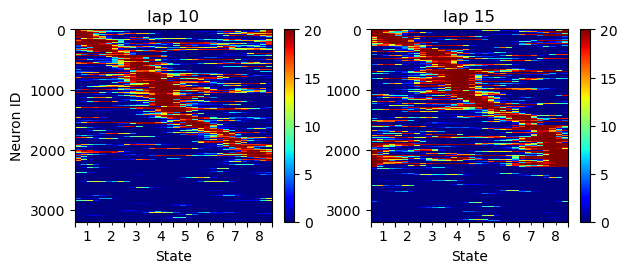

In [301]:
fig, axs = plt.subplots(1, 2,figsize=(7, 2.5))

data_before = CA1_activity_before[:,place_div_idx_before].T
plot_heatmap(data_before, fig, axs[0], title="lap %d"%(before_lap), vmin=0, vmax=max_input_FR, cmap='jet')
axs[0].invert_yaxis()
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
axs[0].set_xticks(x_ticks); axs[0].set_xticklabels([])
axs[0].set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
axs[0].set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
axs[0].set_ylabel("Neuron ID"); axs[0].set_xlabel("State")

data_after = CA1_activity_after[:,place_div_idx_after].T
plot_heatmap(data_after, fig, axs[1], title="lap %d"%(after_lap), vmin=0, vmax=max_input_FR, cmap='jet')
axs[1].invert_yaxis()
axs[1].set_xticks(x_ticks); axs[1].set_xticklabels([])
axs[1].set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
axs[1].set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
axs[1].set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_activity_reward_relocation.png"), dpi=300)
plt.show()

### Fig. 3g, Number of place cell distributed across states 

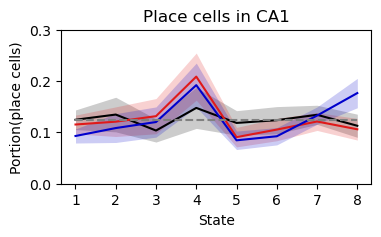

In [306]:
unit_per_plot = unit_gran

ep_list = [5,10,15]
PC_count = np.zeros((len(target_seed),len(ep_list),num_state_total))

for ii,mm in enumerate(target_seed):
    foldername = folder_root+str(mm)
    for ee, load_lap in enumerate(ep_list):
        CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%load_lap))
        CA1_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA1_place_fields.keys()),dtype=int), np.array(list(CA1_place_fields.values())))
        CA1_act = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_%d.npz"%load_lap))["CA1_activity"]
        peaks = find_PF_peak(CA1_act)

        temp_count = [len(np.where((peaks>=unit_per_plot*ss)&(peaks<unit_per_plot*(ss+1)))[0]) for ss in np.arange(num_state_total,dtype=int)]
        
        PC_count[ii,ee,:] = temp_count/np.sum(temp_count)

fig, ax = plt.subplots(1, 1, figsize=(4, 2))

xx = np.arange(PC_count.shape[-1],dtype=int)+1

ax = plot_shaded(xx, PC_count.mean(0)[0], PC_count.std(0)[0], ax, color=colors[4])
ax = plot_shaded(xx, PC_count.mean(0)[1], PC_count.std(0)[1], ax, color=colors[9])
ax = plot_shaded(xx, PC_count.mean(0)[2], PC_count.std(0)[2], ax, color=colors[14])

ax.hlines(y=1/num_state_total, xmin=1, xmax=num_state_total, colors='gray', linestyles='dashed')
ax.set_xlabel("State")
ax.set_xticks(xx)

ax.set_yticks(np.linspace(0,0.3,4))
ax.set_ylabel("Portion(place cells)")
ax.set_title("Place cells in CA1")

if save_plot: plt.savefig(os.path.join(plot_path,"statewise_PC_count.png"), dpi=300)
plt.show()

In [ ]:
for ss in [3,7]:
    _,p_val = stats.ttest_1samp(PC_count[:,0,ss],1/num_state_total)
    print("Episode 5, state %d vs. uniform p val: "%(ss+1),p_val)
print("-----")
for ss in [3,7]:
    _,p_val = stats.ttest_1samp(PC_count[:,1,ss],1/num_state_total)
    print("Episode 10, state %d vs. uniform p val: "%(ss+1),p_val)

print("-----")
for ss in [3,7]:
    _,p_val = stats.ttest_1samp(PC_count[:,2,ss],1/num_state_total)
    print("Episode 15, state %d vs. uniform p val: "%(ss+1),p_val)

Episode 5, state 4 vs. uniform p val:  0.12253328955102852
Episode 5, state 8 vs. uniform p val:  0.14184124581158578
-----
Episode 10, state 4 vs. uniform p val:  0.0003942566624565125
Episode 10, state 8 vs. uniform p val:  0.024147428565073882
-----
Episode 15, state 4 vs. uniform p val:  0.0011469399065762776
Episode 15, state 8 vs. uniform p val:  0.00042680600677737657


### Fig. 3i, Population activity evolvement

In [328]:
target_lap = np.arange(1,16)
pop_act = np.zeros((len(target_seed),len(target_lap),unit_gran*num_state_total))

for ii, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    for kk, load_lap in enumerate(target_lap):
        act = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["CA1_activity"]
        pop_act[ii,kk] = act.mean(1)

        del act

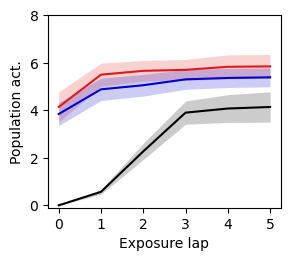

Pop. activity, BG vs. RW at state 4:  5.703251683515257e-06
Pop. activity, BG vs. RW at state 8:  9.574773905395323e-05


In [330]:
fig, ax = plt.subplots(1,1,figsize=(3,2.5))
ss = 3
S4_data = pop_act[:,:,ss*unit_gran:(ss+1)*unit_gran].mean(-1)
ax = plot_shaded(np.arange(6),np.hstack((0,S4_data[:,:5].mean(0))),np.hstack((0,S4_data[:,:5].std(0))),ax,color=colors[4])
ax = plot_shaded(np.arange(6),S4_data[:,4:10].mean(0),S4_data[:,4:10].std(0),ax,color=colors[9])

ss = num_state_total-1
S8_data = pop_act[:,:,ss*unit_gran:(ss+1)*unit_gran].mean(-1)
ax = plot_shaded(np.arange(6),S8_data[:,9:].mean(0),S8_data[:,9:].std(0),ax,color=colors[-1])

ax.set_xticks(np.arange(6)); ax.set_ylim([-.1,8]); ax.set_xlabel("Exposure lap"); ax.set_ylabel("Population act.")
if save_plot: plt.savefig(os.path.join(plot_path,"population_activity.png"), dpi=300)
plt.show()

_, p_value = stats.ttest_ind(S4_data[:,4].flatten(), S4_data[:,9].flatten())
print("Pop. activity, BG vs. RW at state 4: ",p_value)

_, p_value = stats.ttest_ind(S4_data[:,4].flatten(), S8_data[:,-1].flatten())
print("Pop. activity, BG vs. RW at state 8: ",p_value)

### Fig. 3j, Reduction of feature prediction error

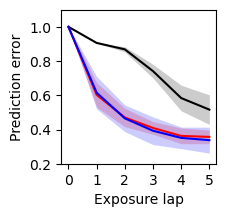

In [335]:
timestep = step_time_length//dA_granularity
error_arr = np.zeros((6,3,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)

    for ee in range(1,6):

        targ_feat = feat_state[0]

        ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%ee))
        error_arr[ee,0,ii] = ff["error_list"][targ_feat*timestep:(targ_feat+1)*timestep+1,targ_feat+2].mean()
        del ff
            

        ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(ee+5)))
        error_arr[ee,1,ii] = ff["error_list"][targ_feat*timestep:(targ_feat+1)*timestep,feat_ID].mean()
        # except: error_arr[ee,1,ii] = ff["error_list"][-timestep:,feat_ID].mean()
        del ff

        targ_feat = feat_state[1]
        ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(ee+10)))
        error_arr[ee,2,ii] = ff["error_list"][targ_feat*timestep:(targ_feat+1)*timestep+1,feat_ID].mean()
        del ff

error_arr[0,:,:] = 1.0
fig, ax = plt.subplots(1,1,figsize=(2,2))
ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,0],error_arr.std(-1)[:,0],ax,color='black')
ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,1],error_arr.std(-1)[:,1],ax,color='red')
ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,2],error_arr.std(-1)[:,2],ax,color='blue')

ax.set_xticks(np.arange(6)); ax.set_xlabel("Exposure lap")
ax.set_ylim([0.2,1.1]); ax.set_yticks(np.arange(1,6)/5); ax.set_ylabel("Prediction error")

if save_plot: plt.savefig(os.path.join(plot_path,"feat_learning_error.png"), dpi=300)
plt.show()

### Fig. 3k, Reward unit activity before relocation

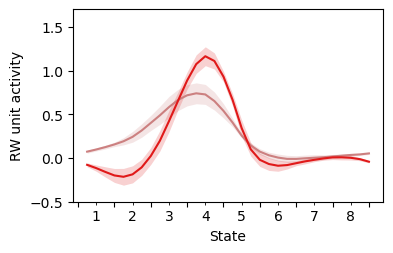

In [352]:
fig, ax = plt.subplots(1,1,figsize=(4,2.5))
for lap in [5,9]:
    plot_shaded(np.arange(num_state_total*unit_gran)+1,feat_pred[0,:,lap].mean(-1),feat_pred[0,:,lap].std(-1),ax,color=colors[lap])

ax.set_ylim([-.5,1.7])
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
ax.set_xticks(x_ticks); ax.set_xticklabels([])
ax.set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("RW unit activity"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"RW_activity_before_relocation.png"), dpi=300)
plt.show()

### Fig. 3l, Reward unit activity after relocation

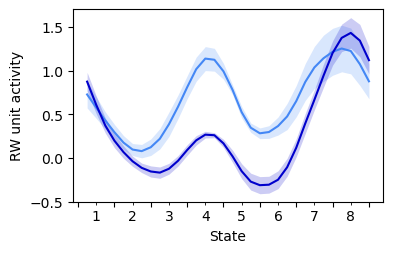

In [351]:
fig, ax = plt.subplots(1,1,figsize=(4,2.5))
for lap in [10,14]:
    plot_shaded(np.arange(num_state_total*unit_gran)+1,feat_pred[0,:,lap].mean(-1),feat_pred[0,:,lap].std(-1),ax,color=colors[lap])

ax.set_ylim([-.5,1.7])
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
ax.set_xticks(x_ticks); ax.set_xticklabels([])
ax.set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("RW unit activity"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"RW_activity_after_relocation.png"), dpi=300)
plt.show()